In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("❌ No GPU detected, running on CPU")

2026-04-25 00:59:15.462297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777078755.643058     140 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777078755.697734     140 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777078756.154307     140 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777078756.154363     140 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777078756.154373     140 computation_placer.cc:177] computation placer alr

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

# Step 1: See all datasets attached to this notebook
print("=== /kaggle/input/ contents ===")
for dataset in os.listdir("/kaggle/input"):
    print(f"\n📁 {dataset}/")
    dataset_path = f"/kaggle/input/{dataset}"
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            full_path = os.path.join(root, file)
            print(f"   {full_path}")

=== /kaggle/input/ contents ===

📁 datasets/
   /kaggle/input/datasets/muhammadasad29/ember-feature-based-dataset/ember/test_ember_2018_final.parquet
   /kaggle/input/datasets/muhammadasad29/ember-feature-based-dataset/ember/train_ember_2018_final.parquet
   /kaggle/input/datasets/muhammadasad29/ember-feature-based-dataset/ember/unlabelled_set_for_pred.parquet


In [5]:
TRAIN_PATH = "/kaggle/input/datasets/muhammadasad29/ember-feature-based-dataset/ember/train_ember_2018_final.parquet"
TEST_PATH  = "/kaggle/input/datasets/muhammadasad29/ember-feature-based-dataset/ember/test_ember_2018_final.parquet"

train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

print("Full Train shape:", train_df.shape)
print("Test shape      :", test_df.shape)
print("\nLabel distribution (train):")
print(train_df["Label"].value_counts())

Full Train shape: (599920, 2342)
Test shape      : (199956, 2342)

Label distribution (train):
Label
0    299991
1    299929
Name: count, dtype: int64


In [6]:
# Centralized model trains on FULL dataset — no split like clients did
central_df = train_df.sample(frac=1, random_state=42)  # shuffle only

print("Central training size:", len(central_df))
print("Client-1 used :", int(0.5 * len(train_df)), "samples (50%, balanced)")
print("Client-2 used :", int(0.5 * len(train_df)), "samples (50%, 80/20 skewed)")
print("Central uses  :", len(central_df), "samples (100%, full)")

Central training size: 599920
Client-1 used : 299960 samples (50%, balanced)
Client-2 used : 299960 samples (50%, 80/20 skewed)
Central uses  : 599920 samples (100%, full)


In [7]:
X_train = central_df.drop(columns=["Label"]).values.astype("float32")
y_train = central_df["Label"].values.astype("float32")

X_test = test_df.drop(columns=["Label"]).values.astype("float32")
y_test = test_df["Label"].values.astype("float32")

# Free the dataframes immediately — no longer needed
del train_df, test_df, central_df
import gc; gc.collect()

print("X_train:", X_train.shape, X_train.dtype)
print("X_test :", X_test.shape,  X_test.dtype)

X_train: (599920, 2341) float32
X_test : (199956, 2341) float32


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Scaling done")

✅ Scaling done


In [9]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1777078825.219824     140 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777078825.225860     140 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,199,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330,689 (5.08 MB)

 Trainable params: 1,330,689 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


I0000 00:00:1777078847.691850     199 service.cc:152] XLA service 0x7a8d600060c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777078847.691904     199 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777078847.691911     199 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777078848.010438     199 cuda_dnn.cc:529] Loaded cuDNN version 91002


  37/1055 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7614 - loss: 0.4963

I0000 00:00:1777078849.799907     199 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1055/1055 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9025 - loss: 0.2346 - val_accuracy: 0.9462 - val_loss: 0.1341
Epoch 2/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9475 - loss: 0.1309 - val_accuracy: 0.9552 - val_loss: 0.1150
Epoch 3/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9554 - loss: 0.1103 - val_accuracy: 0.9552 - val_loss: 0.1164
Epoch 4/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9616 - loss: 0.0949 - val_accuracy: 0.9622 - val_loss: 0.1034
Epoch 5/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9642 - loss: 0.0885 - val_accuracy: 0.9624 - val_loss: 0.1022
Epoch 6/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9672 - loss: 0.0813 - val_accuracy: 0.9630 - val_loss: 0.1036
Epoch 7/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9692 - loss: 0.0759 - val_accuracy: 0.9649 - val_loss: 0.1037
Epoch 8/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9709 - loss: 0.0718 - val_accura

In [11]:
y_pred_prob = model.predict(X_test).ravel()
y_pred      = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

print("=" * 40)
print("   CENTRAL MODEL — TEST RESULTS")
print("=" * 40)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")
print("=" * 40)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malware"]))

6249/6249 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
   CENTRAL MODEL — TEST RESULTS
  Accuracy : 0.9520
  F1 Score : 0.9519
  ROC-AUC  : 0.9882

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.95      0.95     99985
     Malware       0.95      0.95      0.95     99971

    accuracy                           0.95    199956
   macro avg       0.95      0.95      0.95    199956
weighted avg       0.95      0.95      0.95    199956



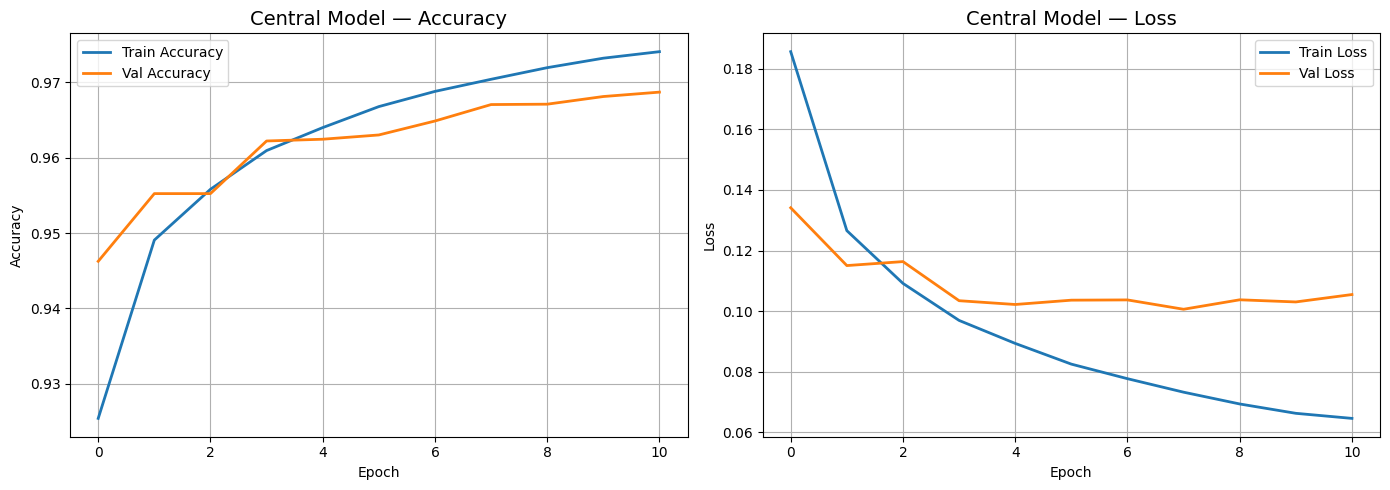

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('Central Model — Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title('Central Model — Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("central_model_training_curves.png", dpi=150)
plt.show()

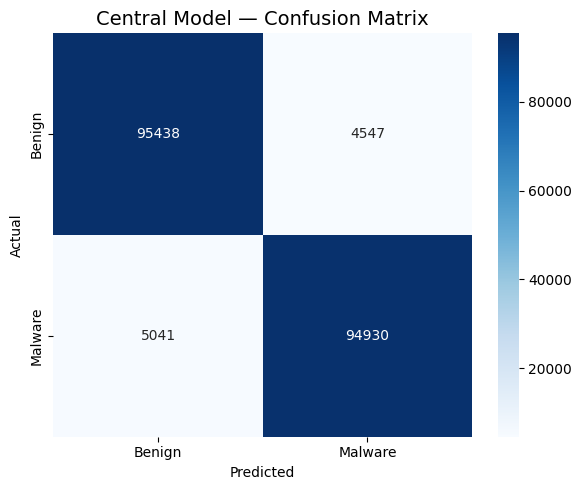

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Benign", "Malware"],
    yticklabels=["Benign", "Malware"]
)
plt.title("Central Model — Confusion Matrix", fontsize=14)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("central_model_confusion_matrix.png", dpi=150)
plt.show()

In [14]:
# Save model
model.save("ember_central_model.keras")
print("✅ Model saved: ember_central_model.keras")

# Save comparison summary for later use
results = {
    "Model"    : ["Client-1 (MLP, IID)",    "Client-2 (Hybrid, non-IID)", "Central (Full Data)"],
    "Data Size": ["299,960 (50%)",           "299,960 (50%, skewed)",      "599,920 (100%)"],
    "Accuracy" : [0.9380,                    0.9108,                        acc],
    "F1 Score" : [0.9385,                    0.9165,                        f1],
    "ROC-AUC"  : [0.9380,                    0.9882,                        roc],
}

results_df = pd.DataFrame(results)
print("\n" + "=" * 65)
print("   LOCAL vs CENTRAL COMPARISON (Global FL model TBD)")
print("=" * 65)
print(results_df.to_string(index=False))
results_df.to_csv("comparison_results.csv", index=False)
print("\n✅ Saved: comparison_results.csv")

✅ Model saved: ember_central_model.keras

   LOCAL vs CENTRAL COMPARISON (Global FL model TBD)
                     Model             Data Size  Accuracy  F1 Score  ROC-AUC
       Client-1 (MLP, IID)         299,960 (50%)  0.938000  0.938500 0.938000
Client-2 (Hybrid, non-IID) 299,960 (50%, skewed)  0.910800  0.916500 0.988200
       Central (Full Data)        599,920 (100%)  0.952049  0.951927 0.988173

✅ Saved: comparison_results.csv


In [15]:
# model = keras.Sequential([
#     layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
#     layers.BatchNormalization(),
#     layers.Dropout(0.3),

#     layers.Dense(256, activation='relu'),
#     layers.BatchNormalization(),
#     layers.Dropout(0.3),

#     layers.Dense(128, activation='relu'),

#     layers.Dense(1, activation='sigmoid')
# ])